In [141]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv3D, MaxPooling3D, Dense, Dropout, Flatten, BatchNormalization
from keras.layers import Activation, GlobalAveragePooling3D
from keras import regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam
import time

In [ ]:
data_dir = "processed_data"
output_model_path = "model_3dcnn_60.h5"

test_size = 0.10
random_state = 42

# Параметры обучения
epochs = 400
dropout_rate=0.5
frames = 20 
num_features = 126 


In [ ]:
actions = []
for item in os.listdir(data_dir):
    item_path = os.path.join(data_dir, item)
    if os.path.isdir(item_path):
        actions.append(item)

actions = np.array(actions)

if len(actions) == 0:
    print(f"ОШИБКА: В {data_dir} не найдено поддиректорий со словами.")

print(f"Найдено {len(actions)} слов.")

Найдено 60 слов.


In [144]:
first_word_dir = os.path.join(data_dir, actions[0])
sequences_dirs = [d for d in os.listdir(first_word_dir) if os.path.isdir(os.path.join(first_word_dir, d))]
sequences = len(sequences_dirs)

print(f"Найдено {len(actions)} слов с {sequences} последовательностями по {frames} кадров.")

label_map = {label: num for num, label in enumerate(actions)}

landmarks, labels = [], []
len(label_map)

Найдено 60 слов с 20 последовательностями по 20 кадров.


60

In [ ]:
for action in actions:
    action_dir = os.path.join(data_dir, action)
    sequence_dirs = [d for d in os.listdir(action_dir) if os.path.isdir(os.path.join(action_dir, d))]
    
    for sequence in sequence_dirs:
        sequence_path = os.path.join(action_dir, sequence)
        
        if not os.path.exists(sequence_path):
            continue
            
        temp = []
        frame_files = sorted([f for f in os.listdir(sequence_path) if f.endswith('.npy')], 
                            key=lambda x: int(x.split('.')[0]))
        
        for frame_file in frame_files:
            frame_path = os.path.join(sequence_path, frame_file)
            try:
                npy = np.load(frame_path)
                temp.append(npy)
            except Exception as e:
                print(f"Ошибка загрузки {frame_path}: {e}")

        if len(temp) == frames:
            landmarks.append(temp)
            labels.append(label_map[action])

In [146]:
X, Y = np.array(landmarks), to_categorical(labels).astype(int)
    
print(f"X shape: {X.shape}, Y shape: {Y.shape}")

X shape: (1277, 20, 126), Y shape: (1277, 60)


In [ ]:
height, width, channels = 7, 6, 3
X_reshaped = X.reshape(X.shape[0], frames, height, width, channels)
X_reshaped

array([[[[[ 6.340e-01,  6.510e-01, -0.000e+00],
          [ 6.000e-01,  6.260e-01, -8.000e-03],
          [ 5.790e-01,  5.550e-01, -1.200e-02],
          [ 5.640e-01,  5.040e-01, -1.800e-02],
          [ 5.540e-01,  4.580e-01, -2.100e-02],
          [ 6.080e-01,  4.720e-01,  2.000e-03]],

         [[ 6.050e-01,  3.930e-01, -1.600e-02],
          [ 5.820e-01,  3.900e-01, -3.000e-02],
          [ 5.660e-01,  4.120e-01, -3.600e-02],
          [ 6.250e-01,  4.720e-01, -2.000e-03],
          [ 6.230e-01,  3.870e-01, -1.800e-02],
          [ 5.960e-01,  3.850e-01, -2.700e-02]],

         [[ 5.810e-01,  4.120e-01, -2.800e-02],
          [ 6.410e-01,  4.800e-01, -9.000e-03],
          [ 6.410e-01,  4.000e-01, -2.100e-02],
          [ 6.130e-01,  3.910e-01, -2.400e-02],
          [ 5.960e-01,  4.090e-01, -2.200e-02],
          [ 6.550e-01,  4.970e-01, -1.700e-02]],

         ...,

         [[ 0.000e+00,  0.000e+00,  0.000e+00],
          [ 0.000e+00,  0.000e+00,  0.000e+00],
          [ 0.000e+

In [148]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, Y_train, Y_test = train_test_split(X_reshaped, Y, test_size=test_size, random_state=random_state, stratify=Y)

print(f"Обучающая выборка: {X_train.shape}, тестовая выборка: {X_test.shape}")

Обучающая выборка: (1149, 20, 7, 6, 3), тестовая выборка: (128, 20, 7, 6, 3)


In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv3D, MaxPooling3D, Dense, Dropout, Flatten, BatchNormalization
from keras.layers import Activation, GlobalAveragePooling3D
from keras import regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam
import time

epochs = 400
dropout_rate = 0.5

_, frames, height, width, channels = X_train.shape
print(f"Форма данных: frames={frames}, height={height}, width={width}, channels={channels}")

model = Sequential()

# Первый блок 3D сверток
model.add(Conv3D(32, kernel_size=(3, 3, 3), padding='same', activation='relu',
               input_shape=(frames, height, width, channels)))
model.add(BatchNormalization())
model.add(Conv3D(32, kernel_size=(3, 3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling3D(pool_size=(2, 2, 2), padding='same'))
model.add(Dropout(0.2))

# Второй блок 3D сверток
model.add(Conv3D(64, kernel_size=(3, 3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv3D(64, kernel_size=(3, 3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling3D(pool_size=(2, 2, 2), padding='same'))
model.add(Dropout(0.25))

# Третий блок 3D сверток
model.add(Conv3D(128, kernel_size=(3, 3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv3D(128, kernel_size=(3, 3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling3D(pool_size=(2, 2, 2), padding='same'))
model.add(Dropout(0.3))

# Четвертый блок 3D сверток
model.add(Conv3D(256, kernel_size=(3, 3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling3D(pool_size=(2, 2, 2), padding='same'))
model.add(Dropout(0.35))

# Глобальный усредненный пулинг
model.add(GlobalAveragePooling3D())

# Полносвязные слои
model.add(Dense(512, kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(dropout_rate))

model.add(Dense(256, kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(dropout_rate/2))

model.add(Dense(128, kernel_regularizer=regularizers.l2(0.0005)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(dropout_rate/3))

# Выходной слой
model.add(Dense(num_classes, activation='softmax'))

optimizer = Adam(
    learning_rate=0.0005,  
    clipnorm=1.0,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy'])

model.summary()

callbacks = [
    # Раннее завершение обучения
    EarlyStopping(
        monitor='val_categorical_accuracy',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    # Снижение скорости обучения
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

Форма данных: frames=20, height=7, width=6, channels=3


c:\Users\pvlmakarova\anaconda3\envs\diploma_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_40 (Conv3D)              │ (None, 20, 7, 6, 32)   │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 20, 7, 6, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_41 (Conv3D)              │ (None, 20, 7, 6, 32)   │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 20, 7, 6, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_37 (MaxPooling3D) │ (None, 10, 4, 3, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 10, 4, 3, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_42 (Conv3D)              │ (None, 10, 4, 3, 64)   │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 10, 4, 3, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_43 (Conv3D)              │ (None, 10, 4, 3, 64)   │       110,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 10, 4, 3, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_38 (MaxPooling3D) │ (None, 5, 2, 2, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 5, 2, 2, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_44 (Conv3D)              │ (None, 5, 2, 2, 128)   │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 5, 2, 2, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_45 (Conv3D)              │ (None, 5, 2, 2, 128)   │       442,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 5, 2, 2, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_39 (MaxPooling3D) │ (None, 3, 1, 1, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 3, 1, 1, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_46 (Conv3D)              │ (None, 3, 1, 1, 256)   │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 3, 1, 1, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_40 (MaxPooling3D) │ (None, 2, 1, 1, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,055,068 (7.84 MB)

 Trainable params: 2,051,868 (7.83 MB)

 Non-trainable params: 3,200 (12.50 KB)

In [ ]:
# Обучение модели
import time
start_time = time.time()

history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=epochs,
    batch_size=16,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

In [151]:
# Время обучения
training_time = time.time() - start_time
hours, remainder = divmod(training_time, 3600)
minutes, seconds = divmod(remainder, 60)

print(f"Время обучения модели LSTM: {int(hours)} ч {int(minutes)} мин {int(seconds)} сек")

Время обучения модели LSTM: 0 ч 5 мин 42 сек


In [152]:
# Оценка модели на тестовых данных
predictions = np.argmax(model.predict(X_test), axis=1)
test_labels = np.argmax(Y_test, axis=1)

accuracy = metrics.accuracy_score(test_labels, predictions)
print(f"Точность модели на тестовой выборке: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step 
Точность модели на тестовой выборке: 0.5859


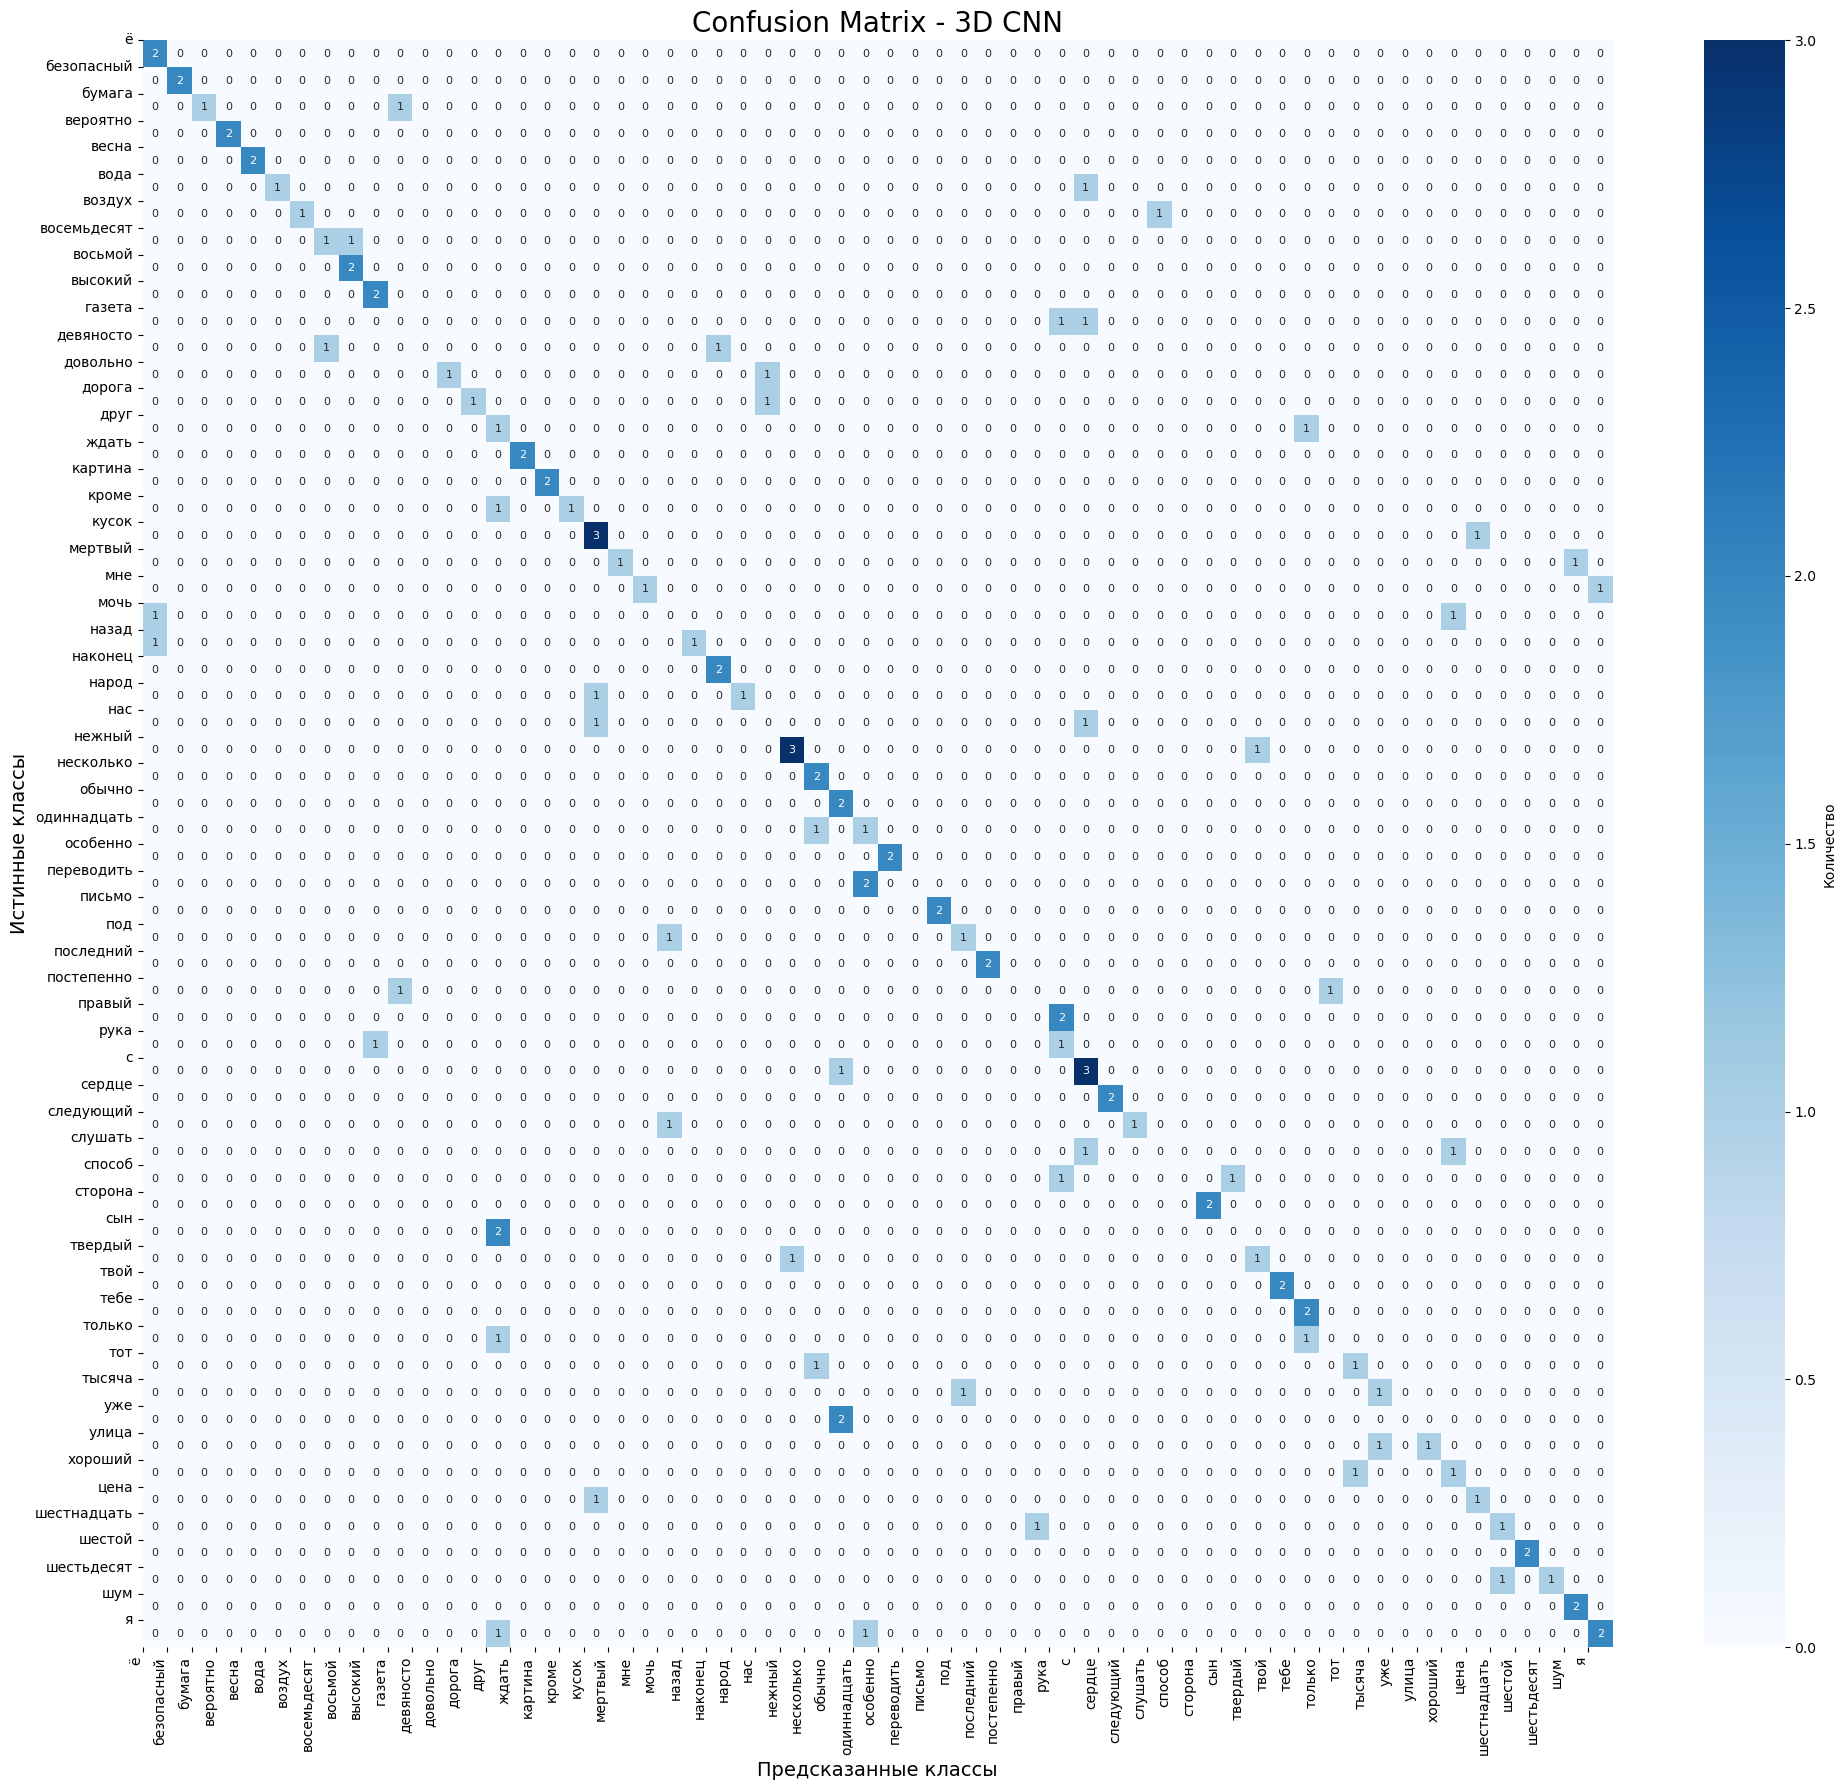

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

plt.figure(figsize=(20, 18))
cm = confusion_matrix(test_labels, predictions)
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar_kws={'label': 'Количество'},
            annot_kws={'size': 8})
plt.title('Confusion Matrix - 3D CNN', fontsize=20)
plt.xlabel('Предсказанные классы', fontsize=14)
plt.ylabel('Истинные классы', fontsize=14)
plt.xticks(range(len(actions)), actions, rotation=90, ha='right')
plt.yticks(range(len(actions)), actions, rotation=0)
plt.tight_layout()
plt.show()

In [153]:
cr = metrics.classification_report(test_labels, predictions, 
                                    target_names=actions, 
                                    digits=3)
print("\nОтчет о классификации:")
print(cr)


Отчет о классификации:
              precision    recall  f1-score   support

           ё      0.500     1.000     0.667         2
  безопасный      1.000     1.000     1.000         2
      бумага      1.000     0.500     0.667         2
    вероятно      1.000     1.000     1.000         2
       весна      1.000     1.000     1.000         2
        вода      1.000     0.500     0.667         2
      воздух      1.000     0.500     0.667         2
 восемьдесят      0.500     0.500     0.500         2
     восьмой      0.667     1.000     0.800         2
     высокий      0.667     1.000     0.800         2
      газета      0.000     0.000     0.000         2
   девяносто      0.000     0.000     0.000         2
    довольно      1.000     0.500     0.667         2
      дорога      1.000     0.500     0.667         2
        друг      0.167     0.500     0.250         2
       ждать      1.000     1.000     1.000         2
     картина      1.000     1.000     1.000         2
   

c:\Users\pvlmakarova\anaconda3\envs\diploma_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pvlmakarova\anaconda3\envs\diploma_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pvlmakarova\anaconda3\envs\diploma_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [ ]:
model.save(output_model_path)

class_mapping = {i: word for i, word in enumerate(actions)}
np.save('class_mapping.npy', class_mapping)

with open('class_mapping.txt', 'w', encoding='utf-8') as f:
    for i, word in enumerate(actions):
        f.write(f"{i}: {word}\n")
